# TouNum — Livrable 1 : Classification binaire *Photo* vs *Autre image*

**Projet** : chaîne automatique de *captioning* d'images pour TouNum (CESI — Data Science)
**Module** : filtre d'entrée du workflow — tri automatique des images numérisées
**Stack imposée** : Python · TensorFlow / Keras · scikit-learn · Pandas · ImageIO · NumPy · Matplotlib

---

### Sommaire

1. [Contexte métier et formalisation du problème](#1)
2. [Configuration de l'environnement](#2)
3. [Indexation et nettoyage des fichiers](#3)
4. [Analyse exploratoire (EDA)](#4)
5. [Prétraitement et mise en cache des images](#5)
6. [Stratégie d'échantillonnage : découpage Train / Validation / Test](#6)
7. [Pipeline de chargement à la volée et Data Augmentation](#7)
8. [Modèle 0 : référence naïve sur métadonnées (détection de biais)](#8)
9. [Modèle 1 : CNN construit *from scratch*](#9)
10. [Modèle 2 : Transfer Learning (EfficientNetB0) et fine-tuning](#10)
11. [Évaluation approfondie et pertinence statistique](#11)
12. [Industrialisation : sauvegarde et fonction `predict_is_photo`](#12)
13. [Conclusion, recul critique et pistes d'amélioration](#13)

<a id="1"></a>
## 1. Contexte métier et formalisation du problème

###  Le besoin de TouNum

TouNum numérise à la chaîne des fonds documentaires papier pour ses clients. L'entreprise veut ajouter à son offre un service de **légendage automatique** (*captioning*) : produire, pour chaque photographie numérisée, une phrase qui en décrit le contenu (« un homme fait du vélo dans une rue »). Ce service facilite ensuite l'indexation, la recherche et la valorisation des archives.

Deux obstacles précèdent le captioning proprement dit :

1. **La qualité variable des numérisations** (flou, bruit) : c'est l'objet du **Livrable 2** (débruitage et amélioration par filtres de convolution et auto-encodeurs).
2. **L'hétérogénéité des documents** : un lot numérisé ne contient pas que des photos. On y trouve des **textes scannés**, des **schémas**, des **croquis** et des **peintures**. Un modèle de captioning entraîné sur des photographies (jeux de type MS-COCO) produira des légendes absurdes sur une page de texte ou un plan technique.

**Ce premier livrable construit le filtre qui se place en tête du workflow** : il décide, pour chaque image, si elle doit poursuivre dans la chaîne de captioning.

### Place du module dans le workflow global

```
                          ┌──────────────────────────────┐
   Images numérisées ───► │ LIVRABLE 1 : filtre binaire  │
   (lots clients)         │ « est-ce une photo ? »       │
                          └──────────────┬───────────────┘
                     P(photo) ≥ seuil    │       P(photo) < seuil
                   ┌─────────────────────┴──────────────────────┐
                   ▼                                            ▼
     ┌───────────────────────────┐                ┌───────────────────────────┐
     │ LIVRABLE 2 : débruitage   │                │ Hors périmètre captioning │
     │ (filtres de convolution / │                │ (archivage, OCR pour les  │
     │  auto-encodeur)           │                │  textes, tri manuel...)   │
     └─────────────┬─────────────┘                └───────────────────────────┘
                   ▼
     ┌───────────────────────────┐
     │ LIVRABLE 3 : captioning   │
     │ CNN (encodeur) + RNN      │──►  « Un chien court sur une plage »
     └───────────────────────────┘
```

### Formalisation en apprentissage supervisé

- **Entrée** : une image couleur ou niveaux de gris, de taille et de format quelconques (JPEG, PNG).
- **Sortie** : la probabilité $\hat p = P(\text{photo} \mid \text{image}) \in [0, 1]$, puis la décision $\hat y = \mathbb{1}[\hat p \geq \tau]$ pour un seuil $\tau$.
- **Étiquettes** : $y = 1$ pour une **photo** (classe positive) ; $y = 0$ pour **toute autre image** (*Painting, Schematics, Sketch, Text*).
- **Données** : environ 41 000 images déjà classées par TouNum, réparties dans 5 dossiers (un par sous-catégorie).

C'est une **classification binaire supervisée** traitée par **réseaux de neurones convolutifs** (CNN), conformément au cahier des charges.

### Niveaux d'exigence fixés par TouNum

| Niveau | Objectif | Difficulté attendue |
|---|---|---|
| **Minimum** | Distinguer une photo d'un **schéma** ou d'un **texte scanné** | Faible : statistiques d'image très différentes (fond blanc, traits fins, peu de couleurs) |
| **Idéal** | Distinguer une photo d'une **peinture** (et d'un croquis) | Élevée : une peinture réaliste est visuellement proche d'une photo |

Le cas **Photo vs Painting** fera donc l'objet d'une évaluation dédiée (section 11.4).

### Coût métier des erreurs et choix des métriques

| Erreur | Signification | Conséquence pour TouNum |
|---|---|---|
| **Faux positif** (FP) | une non-photo est envoyée au captioning | légende absurde livrée au client (perte de crédibilité) et calcul GPU gaspillé |
| **Faux négatif** (FN) | une photo est écartée | la photo n'est pas légendée (perte de valeur, mais rattrapable par un contrôle manuel) |

La classe *Photo* ne représente qu'environ un quart des données. L'**accuracy** seule est donc trompeuse : un modèle qui répondrait toujours « autre » obtiendrait déjà environ 76 %. Nous suivrons donc :

- la **précision** (part de vraies photos parmi les images envoyées au captioning, liée aux FP) ;
- le **rappel** (part des photos effectivement détectées, lié aux FN) ;
- le **F1-score** (moyenne harmonique des deux) ;
- la **ROC-AUC** et la **PR-AUC**, indépendantes du seuil, qui mesurent la capacité de discrimination ;
- des **intervalles de confiance à 95 %** (bootstrap) et un **test de McNemar** pour comparer les modèles rigoureusement.

### Contraintes de conception

- **Automatisation complète** : de la donnée brute (archives ZIP) à la décision, sans étape manuelle.
- **Reproductibilité** : graine aléatoire fixée, découpages sauvegardés, configuration centralisée.
- **Maintenabilité** : un seul point de configuration, des fonctions documentées, un module Python autonome (`tounum_photo_filter.py`) réutilisable par le Livrable 3.
- **Portabilité** : le notebook s'exécute sur **Google Colab (GPU)** comme sur un **poste local (CPU)**. Cette version a été exécutée intégralement sur un poste local **sans GPU** (Intel i7-8850H, 16 Go de RAM), ce qui a guidé certains choix de dimensionnement (taille d'image, mise en cache).

<a id="2"></a>
## 2. Configuration de l'environnement

Toute la configuration (chemins, hyperparamètres) est regroupée dans **une seule cellule**. Pour exécuter le notebook sur un nouveau jeu de données ou un autre environnement, c'est le seul endroit à modifier. C'est un prérequis de maintenabilité pour TouNum.

In [ ]:

# Configuration générale : UNIQUE endroit à modifier pour un autre environnement

import os, sys, platform

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/projet_A5'        # dossier persistant (modèles, résultats) - à adapter
    ZIP_DIR     = '/content/drive/MyDrive/Dataset projet'    # contient les archives "Dataset Livrable 1 - *.zip"
    DATA_DIR    = '/content/unzip_data'                      # extraction sur le disque local (rapide) de la VM
else:
    PROJECT_DIR = 'G:/projet_A5' #fallback sur le disque local (Windows) si pas dans Colab 
    ZIP_DIR     = os.path.join(PROJECT_DIR, 'OneDrive_2026-09-24', 'Dataset projet')
    DATA_DIR    = os.path.join(PROJECT_DIR, 'data', 'livrable_1')

WORK_DIR  = os.path.join(PROJECT_DIR, 'outputs_livrable1')   # tout ce que produit ce notebook
CACHE_DIR = os.path.join(WORK_DIR, 'cache')                  # images redimensionnées, features
MODEL_DIR = os.path.join(WORK_DIR, 'models')                 # modèles entraînés + configuration de production
FIG_DIR   = os.path.join(WORK_DIR, 'figures')                # figures exportées (pour la soutenance)
for d in (WORK_DIR, CACHE_DIR, MODEL_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

# Les poids pré-entraînés Keras sont téléchargés dans le projet (et non dans le profil utilisateur)
os.environ.setdefault('KERAS_HOME', os.path.join(PROJECT_DIR, '.keras'))
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'                     # masque les logs C++ verbeux de TensorFlow

# Parametres de configuration 
# Pensez à justifier le choix de chacun des paramètres
CONFIG = {
    'seed': 42,
    'positive_class': 'Photo',               # nom du dossier de la classe positive (y = 1)
    'valid_ext': ('.jpg', '.jpeg', '.png'),  # extensions acceptées
    'min_side': 32,                          # une image plus petite (en px) est jugée inexploitable
    'draft_size': 320,                       # taille minimale de décodage JPEG (accélération, cf. §5)
    'img_size_cnn': 128,                     # résolution d'entrée du CNN from scratch
    'img_size_tl': 160,                      # résolution d'entrée du modèle de transfer learning
    'val_size': 0.15, 'test_size': 0.15,     # proportions du découpage (train = 70 %)
    'batch_size': 64,
    'epochs_cnn': 12,  'lr_cnn': 1e-3,       # modèle 1
    'epochs_head': 40, 'lr_head': 1e-3,      # modèle 2 (tête sur features gelées)
    'epochs_ft': 3,    'lr_ft': 1e-4,        # modèle 2b (fine-tuning partiel)
    'n_workers': min(12, os.cpu_count() or 4),
}
print(f"Environnement : {'Google Colab' if IN_COLAB else 'poste local'} | {platform.system()} | Python {platform.python_version()}")
print('DATA_DIR =', DATA_DIR)
print('WORK_DIR =', WORK_DIR)

Environnement : poste local | Windows | Python 3.13.2
DATA_DIR = G:/projet_A5\data\livrable_1
WORK_DIR = G:/projet_A5\outputs_livrable1


In [ ]:
# Récupération automatique des données (extraction des archives si besoin)
import glob, zipfile

def extract_datasets(zip_dir, data_dir, pattern='Dataset Livrable 1 - *.zip'):
    '''Décompresse chaque archive "Dataset Livrable 1 - <Catégorie>.zip" dans data_dir,
    sauf si la catégorie y est déjà présente (exécution idempotente).'''
    os.makedirs(data_dir, exist_ok=True)
    for zp in sorted(glob.glob(os.path.join(zip_dir, pattern))):
        category = os.path.basename(zp).split(' - ')[-1].replace('.zip', '')
        target = os.path.join(data_dir, category)
        if os.path.isdir(target) and os.listdir(target):
            print(f'[déjà extrait] {category}')
            continue
        print(f'[extraction]   {zp}')
        with zipfile.ZipFile(zp) as z:
            z.extractall(data_dir)

extract_datasets(ZIP_DIR, DATA_DIR)
print('Sous-dossiers :', sorted(os.listdir(DATA_DIR)))

[déjà extrait] Painting
[déjà extrait] Photo
[déjà extrait] Schematics
[déjà extrait] Sketch
[déjà extrait] Text
Sous-dossiers : ['Painting', 'Photo', 'Schematics', 'Sketch', 'Text']


In [ ]:
# Imports, graines aléatoires et matériel disponible
import io, json, time, hashlib, random, warnings
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import imageio
import imageio.v3 as iio
from PIL import Image, ImageFilter

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from scipy import stats

import tensorflow as tf
import keras
from keras import layers

Image.MAX_IMAGE_PIXELS = None                  # certaines peintures dépassent 89 Mpx (limite anti "bombe" de PIL)
warnings.filterwarnings('ignore', category=UserWarning)

SEED = CONFIG['seed']
random.seed(SEED); np.random.seed(SEED)
keras.utils.set_random_seed(SEED)              # fixe les graines Python, NumPy et TensorFlow

# Charte graphique commune à tout le notebook (une couleur fixe par catégorie)
CAT_COLORS = {'Photo': '#2a78d6', 'Painting': '#eb6834', 'Schematics': '#1baf7a',
              'Sketch': '#eda100', 'Text': '#e87ba4'}
BIN_COLORS = {'Photo': '#2a78d6', 'Autre': '#eb6834'}
MODEL_COLORS = {'M0 Métadonnées': '#8a8985', 'M1 CNN scratch': '#2a78d6',
                'M2 EffNet gelé': '#eb6834', 'M2b EffNet fine-tuné': '#1baf7a'}
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
                     'axes.titleweight': 'bold', 'font.size': 10})

def savefig(name):
    '''Enregistre la figure courante dans FIG_DIR (réutilisable pour la soutenance).'''
    plt.savefig(os.path.join(FIG_DIR, f'{name}.png'), dpi=120, bbox_inches='tight')

print('Versions :')
for name, mod in [('numpy', np), ('pandas', pd), ('matplotlib', matplotlib), ('imageio', imageio),
                  ('scikit-learn', sklearn), ('tensorflow', tf), ('keras', keras)]:
    print(f'  {name:<13}{mod.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print('GPU disponible :', gpus if gpus else 'aucun : exécution sur CPU', '| cœurs CPU :', os.cpu_count())

Versions :
  numpy        2.2.4
  pandas       2.2.3
  matplotlib   3.10.1
  imageio      2.38.0
  scikit-learn 1.7.2
  tensorflow   2.21.0
  keras        3.15.1
GPU disponible : aucun : exécution sur CPU | cœurs CPU : 12


<a id="3"></a>
## 3. Indexation et nettoyage des fichiers

Avant tout apprentissage, on construit un **index** (un `DataFrame` Pandas avec une ligne par fichier) qui sert de référence unique pour toute la suite. On n'itère plus jamais directement sur les dossiers. Cette approche :

- rend le traitement **traçable** (on sait pourquoi chaque fichier a été gardé ou exclu) ;
- permet un **découpage stratifié** reproductible ;
- s'adapte automatiquement à n'importe quel nouveau lot structuré en `DATA_DIR/<catégorie>/<fichiers>`.

**Contrôles appliqués à chaque fichier** :

1. **Extension** : seuls `.jpg`, `.jpeg` et `.png` sont conservés. Les dossiers contiennent des fichiers parasites (par exemple `desktop.ini`, créé par Windows).
2. **Signature binaire** (*magic number*, les premiers octets du fichier) : on vérifie que le contenu correspond réellement à une image, quelle que soit l'extension.
3. **Lisibilité de l'en-tête** : ouverture avec PIL, qui lit uniquement l'en-tête (rapide), pour récupérer format, dimensions et mode colorimétrique.
4. **Taille minimale** : une image de moins de 32 px de côté ne contient aucune information exploitable.

In [ ]:
# Construction de l'index brut
def build_index(data_dir):
    '''Parcourt data_dir/<catégorie>/<fichier> et renvoie un DataFrame (1 ligne par fichier).'''
    rows = []
    for category in sorted(os.listdir(data_dir)):
        cdir = os.path.join(data_dir, category)
        if not os.path.isdir(cdir):
            continue
        for fname in sorted(os.listdir(cdir)):
            path = os.path.join(cdir, fname)
            if os.path.isfile(path):
                rows.append({'path': path.replace('\\', '/'), 'category': category, 'filename': fname,
                             'ext': os.path.splitext(fname)[1].lower(), 'size_bytes': os.path.getsize(path)})
    return pd.DataFrame(rows)

t0 = time.time()
df_raw = build_index(DATA_DIR)
print(f'{len(df_raw):,} fichiers indexés en {time.time() - t0:.1f} s')
display(df_raw.head())
print('\nFichiers par dossier et par extension :')
display(pd.crosstab(df_raw['category'], df_raw['ext'], margins=True, margins_name='Total'))

41,401 fichiers indexés en 2.4 s


,path,category,filename,ext,size_bytes
0,G:/projet_A5/data/livrable_1/Painting/livrable...,Painting,livrable_1.ipynb,.ipynb,312
1,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00001.jpg,.jpg,167430
2,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00002.jpg,.jpg,28800
3,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00003.jpg,.jpg,139530
4,G:/projet_A5/data/livrable_1/Painting/painting...,Painting,painting_00004.jpg,.jpg,115751



Fichiers par dossier et par extension :


ext,.ini,.ipynb,.jpg,.png,Total
category,,,,,
Painting,0,1,10000,0,10001
Photo,0,0,9993,0,9993
Schematics,1,0,10000,0,10001
Sketch,0,0,606,800,1406
Text,0,0,10000,0,10000
Total,1,1,40599,800,41401


In [ ]:
# Inspection de chaque fichier : signature binaire + en-tête image
MAGIC_NUMBERS = {b'\xff\xd8\xff': 'JPEG', b'\x89PNG\r\n\x1a\n': 'PNG', b'GIF8': 'GIF', b'BM': 'BMP', b'RIFF': 'WEBP'}

def inspect_file(path):
    '''Lit la signature et l'en-tête (sans décoder les pixels) : format, dimensions, mode.'''
    info = {'signature': 'INCONNUE', 'format': None, 'width': np.nan, 'height': np.nan,
            'mode': None, 'header_ok': False, 'error': None}
    try:
        with open(path, 'rb') as f:
            head = f.read(8)
        info['signature'] = next((v for k, v in MAGIC_NUMBERS.items() if head.startswith(k)), 'INCONNUE')
        with Image.open(path) as im:
            info.update(format=im.format, width=im.size[0], height=im.size[1], mode=im.mode, header_ok=True)
    except Exception as e:
        info['error'] = type(e).__name__
    return info

t0 = time.time()
with ThreadPoolExecutor(CONFIG['n_workers']) as ex:          # I/O : les threads suffisent
    infos = list(ex.map(inspect_file, df_raw['path']))
df_raw = pd.concat([df_raw, pd.DataFrame(infos)], axis=1)
df_raw['label'] = (df_raw['category'] == CONFIG['positive_class']).astype(int)
print(f'Inspection de {len(df_raw):,} fichiers en {time.time() - t0:.1f} s\n')

print('Signature binaire réelle vs extension :')
display(pd.crosstab([df_raw['category'], df_raw['ext']], df_raw['signature']))
mismatch = df_raw[(df_raw['ext'].isin(['.jpg', '.jpeg']) & (df_raw['signature'] != 'JPEG')) |
                  ((df_raw['ext'] == '.png') & (df_raw['signature'] != 'PNG'))]
print(f"Fichiers dont l'extension ne correspond pas au contenu : {len(mismatch)}")

Inspection de 41,401 fichiers en 39.5 s

Signature binaire réelle vs extension :


signature          BMP  GIF  INCONNUE   JPEG  PNG
category   ext                                   
Painting   .ipynb    0    0         1      0    0
           .jpg      1    1         0   9977   21
Photo      .jpg      0    0         0   9993    0
Schematics .ini      0    0         1      0    0
           .jpg      0    0         0  10000    0
Sketch     .jpg      0    0         0    606    0
           .png      0    0         0      0  800
Text       .jpg      0    0         0  10000    0

Fichiers dont l'extension ne correspond pas au contenu : 23


In [6]:
# ============================================================================
# 3.3  Règles de nettoyage (chaque exclusion est motivée et tracée)
# ============================================================================
df_raw['min_side'] = df_raw[['width', 'height']].min(axis=1)
reason = pd.Series(pd.NA, index=df_raw.index, dtype='object')
reason[~df_raw['ext'].isin(CONFIG['valid_ext'])] = 'extension non image'
reason[reason.isna() & ~df_raw['header_ok']] = 'en-tête illisible'
reason[reason.isna() & (df_raw['min_side'] < CONFIG['min_side'])] = f"trop petite (< {CONFIG['min_side']} px)"
df_raw['exclusion'] = reason

print('Exclusions :')
display(df_raw.groupby(['exclusion', 'category'], dropna=True).size().rename('n').to_frame())
print('Exemples de fichiers exclus :')
display(df_raw.loc[df_raw['exclusion'].notna(), ['category', 'filename', 'ext', 'signature', 'width', 'height', 'exclusion']].head(15))

df = df_raw[df_raw['exclusion'].isna()].reset_index(drop=True)
print(f'Images conservées après nettoyage : {len(df):,} / {len(df_raw):,}')

Exclusions :


n
exclusion             category       
extension non image   Painting      1
                      Schematics    1
trop petite (< 32 px) Schematics  662

Exemples de fichiers exclus :


,category,filename,ext,signature,width,height,exclusion
0,Painting,livrable_1.ipynb,.ipynb,INCONNUE,NaN,NaN,extension non image
19994,Schematics,desktop.ini,.ini,INCONNUE,NaN,NaN,extension non image
19996,Schematics,schematics_00002.jpg,.jpg,JPEG,14.0,35.0,trop petite (< 32 px)
20028,Schematics,schematics_00034.jpg,.jpg,JPEG,14.0,3.0,trop petite (< 32 px)
20037,Schematics,schematics_00043.jpg,.jpg,JPEG,21.0,36.0,trop petite (< 32 px)
20039,Schematics,schematics_00045.jpg,.jpg,JPEG,3.0,3.0,trop petite (< 32 px)
20043,Schematics,schematics_00049.jpg,.jpg,JPEG,21.0,18.0,trop petite (< 32 px)
20044,Schematics,schematics_00050.jpg,.jpg,JPEG,1.0,64.0,trop petite (< 32 px)
20051,Schematics,schematics_00057.jpg,.jpg,JPEG,6.0,36.0,trop petite (< 32 px)
20074,Schematics,schematics_00080.jpg,.jpg,JPEG,50.0,3.0,trop petite (< 32 px)


Images conservées après nettoyage : 40,737 / 41,401


**Lecture** :

- **2 fichiers parasites** (`desktop.ini`, généré par Windows, et un notebook `.ipynb` égaré dans le dossier *Painting*) sont écartés par le contrôle d'extension.
- **662 « schémas » font moins de 32 px** de côté (jusqu'à 1×64 px) : ce sont des icônes ou des fragments extraits de documents, qui ne contiennent aucune information exploitable. Environ 6,6 % de la catégorie *Schematics* est concerné, ce qui montre qu'**un jeu de données client n'est jamais propre**.
- **23 fichiers `.jpg` du dossier *Painting* sont en réalité des PNG, un GIF et un BMP**. On ne peut donc pas faire confiance aux extensions : notre chargement lit le contenu réel du fichier (PIL détecte le format par la signature binaire) et reste robuste.

<a id="4"></a>
## 4. Analyse exploratoire (EDA)

L'objectif est de comprendre les données **avant** de modéliser : l'équilibre des classes, l'hétérogénéité des formats, et les éventuels **biais** qu'un réseau de neurones pourrait exploiter à tort.

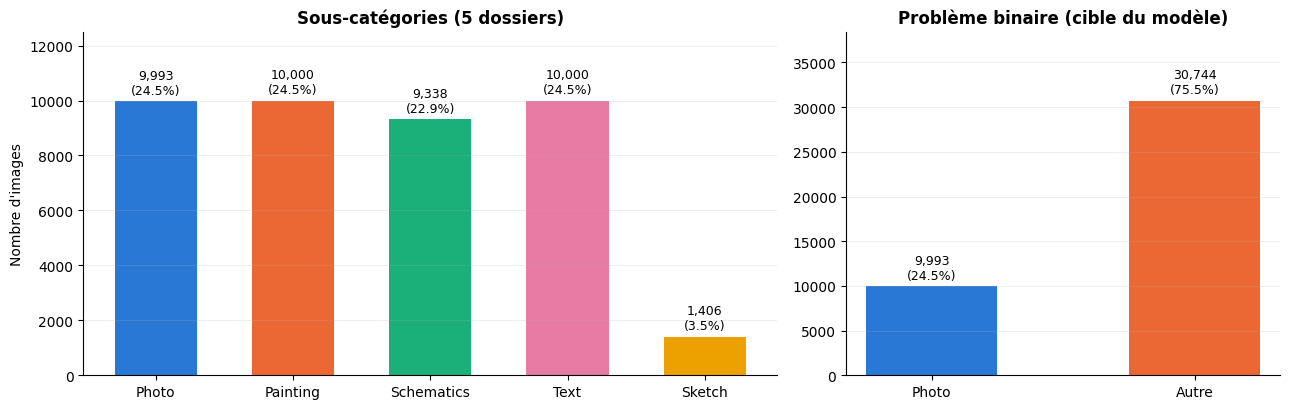

Déséquilibre : 3.08 images 'Autre' pour 1 'Photo'. Un classifieur trivial prédisant toujours 'Autre' aurait une accuracy de 75.5%.


In [7]:
# ============================================================================
# 4.1  Répartition des classes
# ============================================================================
counts = df['category'].value_counts().reindex(['Photo', 'Painting', 'Schematics', 'Text', 'Sketch'])
bin_counts = df['label'].map({1: 'Photo', 0: 'Autre'}).value_counts().reindex(['Photo', 'Autre'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [1.6, 1]})
ax = axes[0]
bars = ax.bar(counts.index, counts.values, color=[CAT_COLORS[c] for c in counts.index], width=0.6)
ax.bar_label(bars, labels=[f'{v:,}\n({v / len(df):.1%})' for v in counts.values], padding=3, fontsize=9)
ax.set_title('Sous-catégories (5 dossiers)'); ax.set_ylabel("Nombre d'images"); ax.set_ylim(0, counts.max() * 1.25)
ax.grid(axis='x', visible=False)
ax = axes[1]
bars = ax.bar(bin_counts.index, bin_counts.values, color=[BIN_COLORS[c] for c in bin_counts.index], width=0.5)
ax.bar_label(bars, labels=[f'{v:,}\n({v / len(df):.1%})' for v in bin_counts.values], padding=3, fontsize=9)
ax.set_title('Problème binaire (cible du modèle)'); ax.set_ylim(0, bin_counts.max() * 1.25)
ax.grid(axis='x', visible=False)
plt.tight_layout(); savefig('eda_repartition_classes'); plt.show()

ratio = bin_counts['Autre'] / bin_counts['Photo']
print(f"Déséquilibre : {ratio:.2f} images 'Autre' pour 1 'Photo'. "
      f"Un classifieur trivial prédisant toujours 'Autre' aurait une accuracy de {bin_counts['Autre'] / len(df):.1%}.")

**Lecture** :

- La classe positive *Photo* représente environ **24 %** des images. Le problème est **déséquilibré** (environ 3 négatifs pour 1 positif). On compensera avec une **pondération des classes** dans la fonction de coût et des métriques adaptées (F1, AUC).
- La classe négative est **composite**. *Sketch* est sous-représentée (environ 3 %) : il faudra vérifier que le modèle ne la néglige pas (analyse par sous-catégorie, §11.3). Le découpage sera **stratifié sur la sous-catégorie**, et pas seulement sur l'étiquette binaire.

,n,largeur_med,hauteur_med,largeur_max,hauteur_max,ratio_med,mpx_med,ko_med,octets_par_px
category,,,,,,,,,
Photo,9993,640.0,480.0,640.0,640.0,1.33,0.27,152.89,0.58
Painting,10000,800.0,800.0,8169.0,8311.0,0.91,0.71,169.08,0.25
Schematics,9338,715.0,495.0,10200.0,9894.0,1.38,0.36,37.51,0.12
Text,10000,595.0,842.0,612.0,842.0,0.71,0.50,61.04,0.15
Sketch,1406,1111.0,1111.0,1111.0,1111.0,1.00,1.23,32.86,0.04


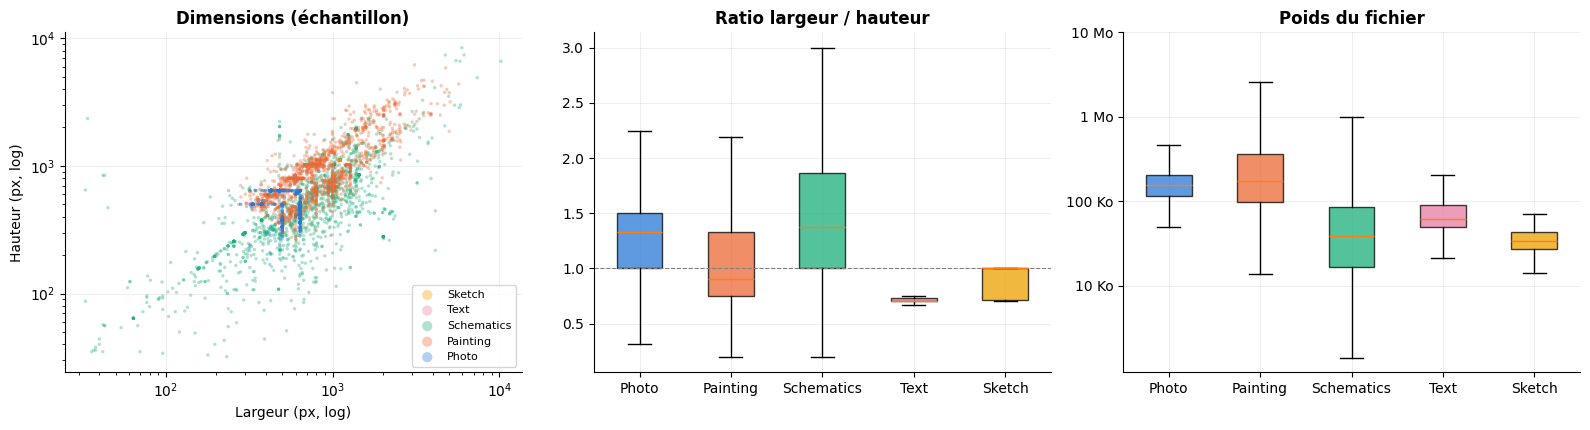

In [11]:
# ============================================================================
# 4.2  Dimensions, formats, modes colorimétriques et poids des fichiers
# ============================================================================
df['aspect'] = df['width'] / df['height']
df['megapixels'] = df['width'] * df['height'] / 1e6
df['bytes_per_px'] = df['size_bytes'] / (df['width'] * df['height'])
order = ['Photo', 'Painting', 'Schematics', 'Text', 'Sketch']

summary = df.groupby('category').agg(
    n=('path', 'size'),
    largeur_med=('width', 'median'), hauteur_med=('height', 'median'),
    largeur_max=('width', 'max'), hauteur_max=('height', 'max'),
    ratio_med=('aspect', 'median'), mpx_med=('megapixels', 'median'),
    ko_med=('size_bytes', lambda s: s.median() / 1024), octets_par_px=('bytes_per_px', 'median'),
).reindex(order).round(2)
display(summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for cat in order[::-1]:                                   # Photo tracée en dernier (au premier plan)
    sub = df[df['category'] == cat].sample(min(1500, (df['category'] == cat).sum()), random_state=SEED)
    axes[0].scatter(sub['width'], sub['height'], s=6, alpha=0.35, color=CAT_COLORS[cat], label=cat, edgecolors='none')
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Largeur (px, log)'); axes[0].set_ylabel('Hauteur (px, log)')
axes[0].set_title('Dimensions (échantillon)'); axes[0].legend(markerscale=3, fontsize=8)

data = [df.loc[df['category'] == c, 'aspect'].clip(0.2, 3) for c in order]
bp = axes[1].boxplot(data, tick_labels=order, showfliers=False, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(CAT_COLORS[c]); patch.set_alpha(0.75)
axes[1].axhline(1, color='gray', lw=0.8, ls='--'); axes[1].set_title('Ratio largeur / hauteur')

data = [np.log10(df.loc[df['category'] == c, 'size_bytes']) for c in order]
bp = axes[2].boxplot(data, tick_labels=order, showfliers=False, patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], order):
    patch.set_facecolor(CAT_COLORS[c]); patch.set_alpha(0.75)
axes[2].set_yticks([4, 5, 6, 7], ['10 Ko', '100 Ko', '1 Mo', '10 Mo']); axes[2].set_title('Poids du fichier')
plt.tight_layout(); savefig('eda_dimensions'); plt.show()

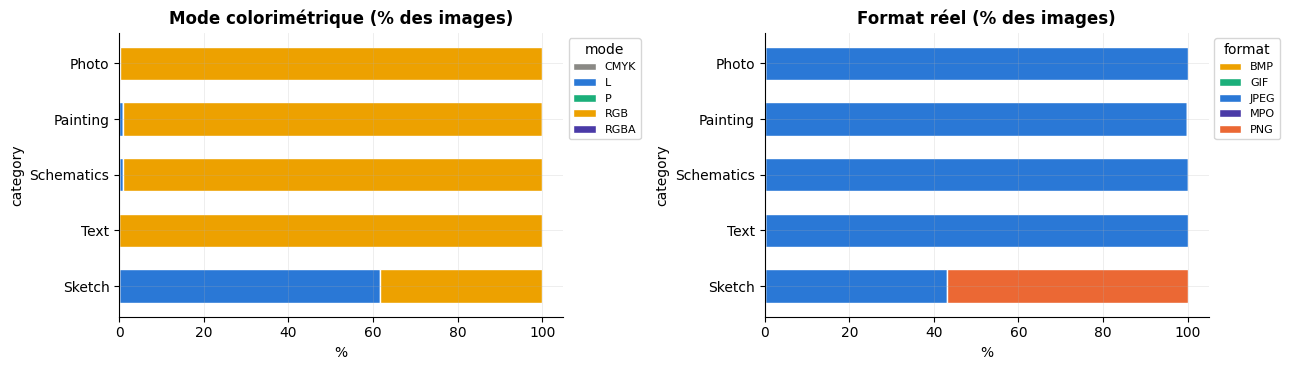

Effectifs par mode :


mode,CMYK,L,P,RGB,RGBA
category,,,,,
Photo,0,25,0,9968,0
Painting,1,82,5,9907,5
Schematics,0,74,0,9264,0
Text,0,0,0,10000,0
Sketch,0,868,0,538,0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
modes = pd.crosstab(df['category'], df['mode'], normalize='index').reindex(order) * 100
modes.plot(kind='barh', stacked=True, ax=axes[0], color=['#8a8985', '#2a78d6', '#1baf7a', '#eda100', '#4a3aa7'][:modes.shape[1]],
           width=0.6, edgecolor='white', linewidth=1)
axes[0].set_title('Mode colorimétrique (% des images)'); axes[0].set_xlabel('%'); axes[0].invert_yaxis()
axes[0].legend(title='mode', bbox_to_anchor=(1, 1), fontsize=8)
fmts = pd.crosstab(df['category'], df['format'], normalize='index').reindex(order) * 100
FMT_COLORS = {'JPEG': '#2a78d6', 'PNG': '#eb6834', 'GIF': '#1baf7a', 'BMP': '#eda100', 'MPO': '#4a3aa7'}
fmts.plot(kind='barh', stacked=True, ax=axes[1], color=[FMT_COLORS.get(f, '#8a8985') for f in fmts.columns],
          width=0.6, edgecolor='white', linewidth=1)
axes[1].set_title('Format réel (% des images)'); axes[1].set_xlabel('%'); axes[1].invert_yaxis()
axes[1].legend(title='format', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout(); savefig('eda_modes_formats'); plt.show()
print('Effectifs par mode :'); display(pd.crosstab(df['category'], df['mode']).reindex(order))

**Lecture** :

- **Formats hétérogènes** : les images vont de quelques dizaines de pixels à plus de 6 000 px de côté, avec des ratios variés (pages de texte en portrait A4, photos en paysage 4:3). Il faudra **normaliser la taille** à l'entrée du réseau (§5).
- **Modes mixtes** : on trouve du RGB, des niveaux de gris (`L`), et du PNG pour les croquis (parfois avec palette ou transparence). Le prétraitement doit **tout convertir en RGB 3 canaux**, avec composition sur fond blanc pour la transparence.
- **Point d'attention (biais de collecte)** : les photos ont presque toutes une taille bornée à 640 px (signature d'un corpus de type COCO), alors que les peintures sont souvent très grandes. Un modèle pourrait apprendre « petite image = photo » au lieu du contenu visuel. Ce risque de raccourci (*shortcut learning*) est quantifié en §8 avec un modèle volontairement naïf.

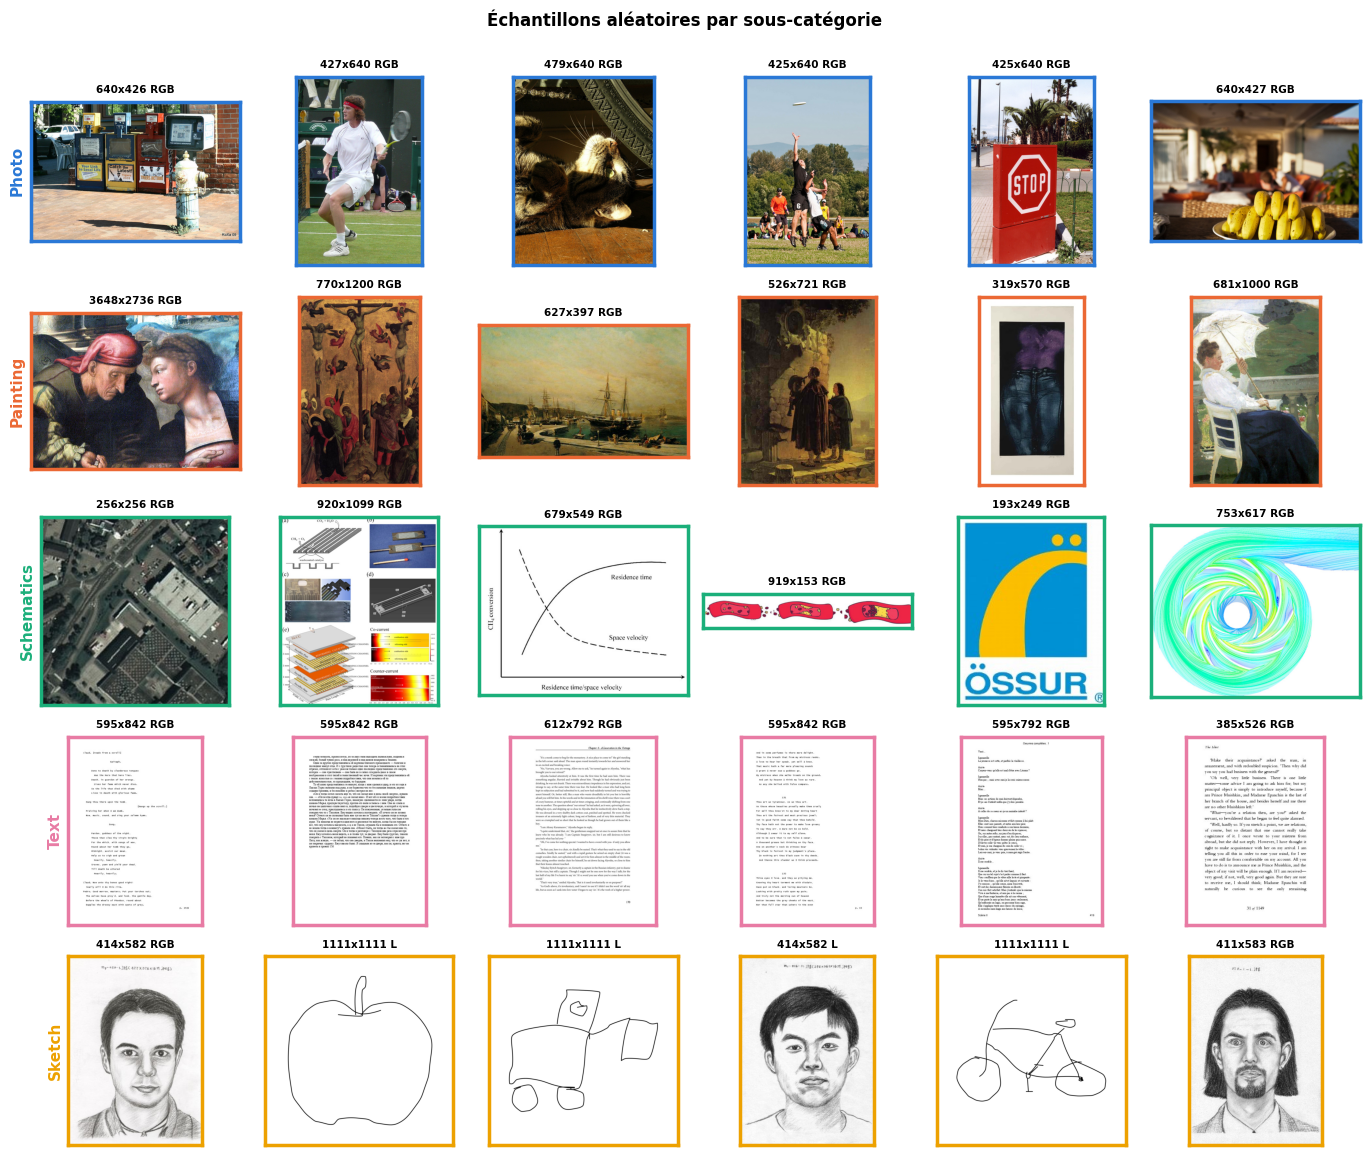

In [10]:
# ============================================================================
# 4.3  Échantillons par catégorie (chargement avec ImageIO)
# ============================================================================
n_per_cat = 6
fig, axes = plt.subplots(len(order), n_per_cat, figsize=(2.3 * n_per_cat, 2.3 * len(order)))
for r, cat in enumerate(order):
    sample = df[df['category'] == cat].sample(n_per_cat, random_state=SEED + 1)
    for c, (_, row) in enumerate(sample.iterrows()):
        img = iio.imread(row['path'])                   # lecture ImageIO (ndarray H x W [x C])
        ax = axes[r, c]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for s in ax.spines.values():
            s.set_visible(True); s.set_color(CAT_COLORS[cat]); s.set_linewidth(2.5)
        ax.set_title(f"{int(row['width'])}x{int(row['height'])} {row['mode']}", fontsize=7.5)
        if c == 0:
            ax.set_ylabel(cat, fontsize=11, fontweight='bold', color=CAT_COLORS[cat])
plt.suptitle('Échantillons aléatoires par sous-catégorie', fontweight='bold', y=1.0)
plt.tight_layout(); savefig('eda_echantillons'); plt.show()

**Lecture** : les *Schematics* et *Text* ont des fonds blancs, des traits fins et une palette de couleurs réduite : ils sont faciles à séparer des photos. Les *Sketch* sont des dessins au trait, souvent en niveaux de gris. Les *Painting*, enfin, contiennent des scènes, des textures et des couleurs proches de celles d'une photo : ce sont elles qui feront la difficulté du problème.

⚠️ **Bruit d'étiquetage** : l'échantillon révèle déjà des cas ambigus. Le dossier *Schematics* contient une **vue aérienne** (visuellement, une photographie) et un **logo**. Le dossier *Painting* contient la **photo d'un tableau accroché au mur**. Ces images, étiquetées « autre », ressemblent à des photos : elles plafonneront les performances atteignables et devront être examinées lors de l'analyse d'erreurs (§11.5).

<a id="5"></a>
## 5. Prétraitement et mise en cache des images

### 5.1 Choix de prétraitement

Un réseau de neurones attend des tenseurs de **taille fixe**. Chaque image passe donc par la même chaîne :

| Étape | Choix | Justification |
|---|---|---|
| Décodage | PIL, avec `draft()` pour les JPEG | Le JPEG est stocké en blocs DCT : `draft` décode directement à 1/2, 1/4 ou 1/8 de la résolution. Le décodage des grandes peintures (jusqu'à 16 Mo) devient 5 à 10 fois plus rapide, sans perte utile puisqu'on réduit ensuite l'image. |
| Couleur | Conversion en **RGB** ; transparence composée sur **fond blanc** | Gère uniformément les modes L, P, RGBA et CMYK observés en §4. |
| Taille | Redimensionnement **bilinéaire** en carré (128 px pour le CNN, 160 px pour le transfer learning) | Compromis entre information et coût de calcul (entraînement sur CPU). Le rapport d'aspect n'est pas conservé : c'est volontaire, pour ne pas exposer le format de l'image comme indice (voir §8). |
| Valeurs | `uint8` [0, 255] en cache, normalisées **dans le modèle** | La normalisation (couche `Rescaling`, ou prétraitement interne d'EfficientNet) fait partie du modèle sauvegardé : aucun risque d'oubli en production. |

### 5.2 Pourquoi un cache ?

Décoder et redimensionner 40 000 images à **chaque epoch** coûterait plusieurs minutes par epoch. On les traite **une seule fois** et on les stocke sous forme de tableaux NumPy compacts (`.npy`, environ 2 Go en 128 px et 3 Go en 160 px), lus ensuite par *memory-mapping*. C'est la réponse concrète à la contrainte du sujet : ne pas saturer la RAM avec des milliers d'images en pleine résolution.

**Garantie de cohérence entraînement / production** : la même fonction `load_image_array` sert à construire le cache et, en production, dans `predict_is_photo` (§12). Un test d'égalité stricte le vérifie en §12.

La même passe calcule aussi, pour chaque image :

- une **empreinte MD5** du fichier et de la miniature, pour détecter les **doublons** ;
- quelques **statistiques de pixels** (luminosité, contraste, saturation, proportion de blanc, densité de contours) qui décrivent les différences visuelles entre catégories.

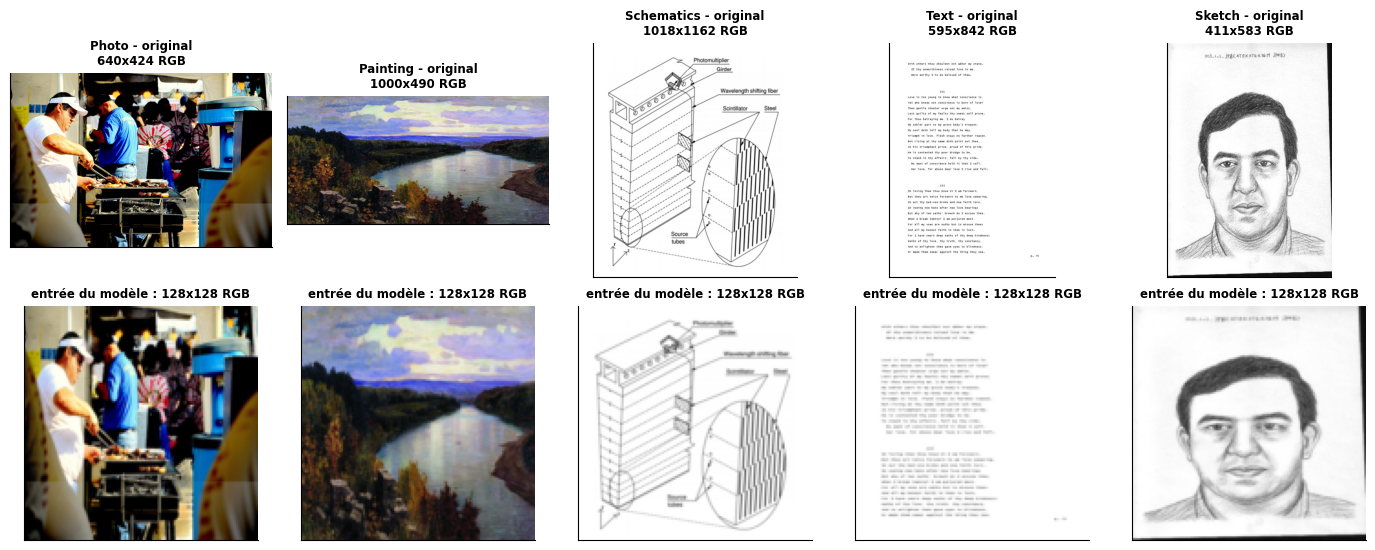

In [13]:
# ============================================================================
# 5.3  Fonctions de chargement (réutilisées telles quelles en production)
# ============================================================================
DRAFT_SIZE = CONFIG['draft_size']

def to_rgb(im):
    '''Convertit n'importe quel mode PIL (L, P, RGBA, CMYK...) en RGB ; la transparence est posée sur du blanc.'''
    if im.mode in ('RGBA', 'LA') or (im.mode == 'P' and 'transparency' in im.info):
        im = im.convert('RGBA')
        background = Image.new('RGBA', im.size, (255, 255, 255, 255))
        im = Image.alpha_composite(background, im)
    return im.convert('RGB')

def decode_image(src):
    '''Ouvre une image (chemin ou flux binaire) et la décode en RGB.
    Pour les JPEG, draft() décode directement à une résolution réduite (>= DRAFT_SIZE px).'''
    im = Image.open(src)
    if im.format == 'JPEG':
        im.draft('RGB', (DRAFT_SIZE, DRAFT_SIZE))
    return to_rgb(im)

def resize_array(im, size):
    '''Redimensionne une image PIL en carré size x size et renvoie un tableau uint8 (size, size, 3).'''
    return np.asarray(im.resize((size, size), Image.BILINEAR), dtype=np.uint8)

def load_image_array(src, size):
    '''Chaîne complète : fichier -> tableau uint8 (size, size, 3), prêt pour le modèle.'''
    return resize_array(decode_image(src), size)

def pixel_stats(arr):
    '''Descripteurs simples de l'apparence d'une image (tableau RGB uint8).'''
    x = arr.astype(np.float32) / 255.0
    gray = x.mean(axis=2)
    mx, mn = x.max(axis=2), x.min(axis=2)
    saturation = np.where(mx > 0, (mx - mn) / np.maximum(mx, 1e-6), 0)
    edges = np.abs(np.diff(gray, axis=0)).mean() + np.abs(np.diff(gray, axis=1)).mean()
    return {'brightness': gray.mean(), 'contrast': gray.std(), 'saturation': saturation.mean(),
            'white_ratio': (gray > 0.92).mean(), 'edge_density': edges}

# Démonstration sur une image de chaque catégorie
fig, axes = plt.subplots(2, 5, figsize=(14, 5.6))
for c, cat in enumerate(order):
    row = df[df['category'] == cat].iloc[3]
    original = iio.imread(row['path'])
    axes[0, c].imshow(original, cmap='gray' if original.ndim == 2 else None)
    axes[0, c].set_title(f"{cat} - original\n{original.shape[1]}x{original.shape[0]} {row['mode']}", fontsize=8.5)
    axes[1, c].imshow(load_image_array(row['path'], CONFIG['img_size_cnn']))
    axes[1, c].set_title(f"entrée du modèle : {CONFIG['img_size_cnn']}x{CONFIG['img_size_cnn']} RGB", fontsize=8.5)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
plt.tight_layout(); savefig('pretraitement_exemples'); plt.show()

In [14]:
# ============================================================================
# 5.4  Construction du cache (une seule passe sur les fichiers, parallélisée)
#      Idempotent : si le cache existe et correspond à l'index, il est simplement rechargé.
# ============================================================================
from numpy.lib.format import open_memmap

S1, S2 = CONFIG['img_size_cnn'], CONFIG['img_size_tl']
X1_PATH = os.path.join(CACHE_DIR, f'images_{S1}.npy')
X2_PATH = os.path.join(CACHE_DIR, f'images_{S2}.npy')
META_PATH = os.path.join(CACHE_DIR, 'cache_index.csv')

def process_file(path):
    '''Lit le fichier une seule fois : empreinte MD5, décodage, 2 résolutions, statistiques de pixels.'''
    try:
        with open(path, 'rb') as f:
            raw = f.read()
        im = decode_image(io.BytesIO(raw))
        a1, a2 = resize_array(im, S1), resize_array(im, S2)
        out = {'md5_file': hashlib.md5(raw).hexdigest(), 'md5_thumb': hashlib.md5(a1.tobytes()).hexdigest(),
               'decode_ok': True, 'decode_error': None, **pixel_stats(a1)}
        return out, a1, a2
    except Exception as e:
        return {'decode_ok': False, 'decode_error': f'{type(e).__name__}: {e}'[:120]}, None, None

cache_valid = False
if os.path.exists(META_PATH) and os.path.exists(X1_PATH) and os.path.exists(X2_PATH):
    meta = pd.read_csv(META_PATH)
    cache_valid = len(meta) == len(df) and (meta['path'].values == df['path'].values).all()

if cache_valid:
    print('Cache existant et cohérent avec l\'index : rechargement.')
else:
    N = len(df)
    X1w = open_memmap(X1_PATH, mode='w+', dtype=np.uint8, shape=(N, S1, S1, 3))
    X2w = open_memmap(X2_PATH, mode='w+', dtype=np.uint8, shape=(N, S2, S2, 3))
    records, t0 = [], time.time()
    with ThreadPoolExecutor(CONFIG['n_workers']) as ex:
        for i, (rec, a1, a2) in enumerate(ex.map(process_file, df['path'])):
            records.append(rec)
            if a1 is not None:
                X1w[i], X2w[i] = a1, a2
            if (i + 1) % 5000 == 0 or i + 1 == N:
                el = time.time() - t0
                print(f'  {i + 1:>6,}/{N:,} images | {el / 60:4.1f} min | {(i + 1) / el:5.0f} img/s')
    X1w.flush(); X2w.flush(); del X1w, X2w
    meta = pd.concat([df[['path']], pd.DataFrame(records)], axis=1)
    meta.to_csv(META_PATH, index=False)
    print(f'Cache construit en {(time.time() - t0) / 60:.1f} min')

df = df.merge(meta, on='path', how='left')
df['cache_idx'] = np.arange(len(df))           # ligne correspondante dans les tableaux .npy
X1 = np.load(X1_PATH)                           # 128 px : ~2 Go, chargé en RAM (accès aléatoire rapide à l'entraînement)
X2 = np.load(X2_PATH, mmap_mode='r')            # 160 px : lu à la demande depuis le disque (memory-mapping)
print(f'X1 {X1.shape} {X1.nbytes / 1e9:.2f} Go (RAM) | X2 {X2.shape} {X2.nbytes / 1e9:.2f} Go (memmap)')
print(f"Échecs de décodage : {(~df['decode_ok']).sum()}")
display(df.loc[~df['decode_ok'], ['category', 'filename', 'decode_error']].head())

   5,000/40,737 images |  0.6 min |   132 img/s
  10,000/40,737 images |  1.1 min |   151 img/s
  15,000/40,737 images |  1.5 min |   164 img/s
  20,000/40,737 images |  1.9 min |   171 img/s
  25,000/40,737 images |  2.3 min |   180 img/s
  30,000/40,737 images |  2.7 min |   187 img/s
  35,000/40,737 images |  3.2 min |   181 img/s
  40,000/40,737 images |  3.8 min |   175 img/s
  40,737/40,737 images |  3.9 min |   175 img/s
Cache construit en 3.9 min


MemoryError: Unable to allocate 1.86 GiB for an array with shape (2002305024,) and data type uint8

In [ ]:
# ============================================================================
# 5.5  Doublons : fuite de données (train <-> test) et bruit d'étiquetage
# ============================================================================
ok = df['decode_ok']
for key, label in [('md5_file', 'fichiers identiques octet par octet'), ('md5_thumb', 'miniatures 128 px identiques')]:
    dup = df[ok & df.duplicated(key, keep=False)]
    groups = dup.groupby(key)['category'].agg(lambda s: tuple(sorted(set(s))))
    print(f"{label:<38}: {len(dup):>5} images dans {dup[key].nunique():>4} groupes "
          f"| dont groupes multi-catégories : {(groups.apply(len) > 1).sum()}")

# Groupe de doublons = même fichier OU même miniature
df['dup_key'] = df['md5_thumb'].where(ok, df['path'])
grp = df[ok].groupby('dup_key')['category'].agg(lambda s: set(s))
conflict_keys = set(grp[grp.apply(len) > 1].index)                       # même image, étiquettes différentes
df['is_conflict'] = df['dup_key'].isin(conflict_keys)
df['is_dup_copy'] = df.duplicated('dup_key', keep='first') & ~df['is_conflict']

print('\nDoublons intra-catégorie (copies surnuméraires) par catégorie :')
display(df[df['is_dup_copy']]['category'].value_counts().to_frame('copies'))
print('Images présentes dans plusieurs catégories (étiquette contradictoire) :')
display(df[df['is_conflict']].groupby('dup_key')['category'].agg(lambda s: ' / '.join(sorted(s))).value_counts().to_frame('groupes'))

if conflict_keys:
    keys = list(conflict_keys)[:4]
    fig, axes = plt.subplots(1, len(keys) * 2, figsize=(3 * len(keys) * 2, 3))
    k = 0
    for key in keys:
        for _, r in df[df['dup_key'] == key].head(2).iterrows():
            axes[k].imshow(X1[r['cache_idx']]); axes[k].set_title(f"{r['category']}\n{r['filename']}", fontsize=8)
            axes[k].axis('off'); k += 1
    plt.suptitle("Exemples d'images en conflit d'étiquette", fontweight='bold'); plt.tight_layout(); plt.show()

In [ ]:
# ============================================================================
# 5.6  Application des exclusions et bilan du nettoyage
# ============================================================================
df['exclusion'] = pd.NA
df.loc[~df['decode_ok'], 'exclusion'] = 'décodage impossible'
df.loc[df['exclusion'].isna() & df['is_conflict'], 'exclusion'] = 'doublon inter-catégories (étiquette ambiguë)'
df.loc[df['exclusion'].isna() & df['is_dup_copy'], 'exclusion'] = 'doublon intra-catégorie'

bilan = pd.concat([df_raw[df_raw['exclusion'].notna()][['category', 'exclusion']],
                   df[df['exclusion'].notna()][['category', 'exclusion']]])
display(pd.crosstab(bilan['exclusion'], bilan['category'], margins=True, margins_name='Total'))

df = df[df['exclusion'].isna()].reset_index(drop=True)
print(f'Jeu de données final : {len(df):,} images '
      f"({df['label'].sum():,} photos / {(1 - df['label']).sum():,} autres) sur {len(df_raw):,} fichiers bruts")

In [ ]:
# ============================================================================
# 5.7  Ce que « voit » un réseau : statistiques de pixels par catégorie
# ============================================================================
feats = ['brightness', 'contrast', 'saturation', 'white_ratio', 'edge_density']
titles = ['Luminosité moyenne', 'Contraste (écart-type)', 'Saturation moyenne', 'Proportion de pixels blancs', 'Densité de contours']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
for ax, f, t in zip(axes, feats, titles):
    bp = ax.boxplot([df.loc[df['category'] == c, f] for c in order], tick_labels=order, showfliers=False,
                    patch_artist=True, widths=0.55)
    for patch, c in zip(bp['boxes'], order):
        patch.set_facecolor(CAT_COLORS[c]); patch.set_alpha(0.75)
    ax.set_title(t, fontsize=10); ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); savefig('eda_stats_pixels'); plt.show()
display(df.groupby('category')[feats].median().reindex(order).round(3))

**Lecture** : *Text*, *Schematics* et *Sketch* se distinguent nettement des photos par une **forte proportion de blanc** et une **faible saturation**. Ce sont des indices de bas niveau que les premières couches convolutives captent facilement. Les *Painting* ont au contraire des distributions **proches de celles des photos** sur tous ces descripteurs. Leur séparation exige des indices plus fins : texture de la touche de pinceau, grain du capteur photo, cohérence de l'éclairage et de la perspective. C'est ce qui justifie des modèles convolutifs **profonds**, capables d'apprendre des motifs hiérarchiques plutôt que de simples statistiques globales.

<a id="6"></a>
## 6. Stratégie d'échantillonnage : découpage Train / Validation / Test

| Jeu | Part | Rôle |
|---|---|---|
| **Train** | 70 % | Apprentissage des poids |
| **Validation** | 15 % | *Early stopping*, choix des hyperparamètres, **choix du seuil de décision** et **choix du modèle final** |
| **Test** | 15 % | Estimation finale, **non biaisée**, des performances ; consulté une seule fois, à la fin |

- **Stratification sur la sous-catégorie** (`category`, 5 modalités) et non sur l'étiquette binaire seule : chaque jeu contient la même proportion de *Painting*, *Sketch*, etc. Sans cela, la rare catégorie *Sketch* pourrait être sous-représentée dans le test, et l'évaluation par sous-catégorie serait instable.
- Les **doublons ont été retirés avant le découpage** (§5.5) : une même image ne peut pas se retrouver à la fois en train et en test, ce qui gonflerait artificiellement les scores (fuite de données).
- **Déséquilibre des classes** : on conserve toutes les données (le sous-échantillonnage ferait perdre de l'information). On compense avec une **pondération des classes** (`class_weight`) dans la fonction de coût : une erreur sur une photo pèse environ 3 fois plus qu'une erreur sur une autre image.

In [ ]:
# ============================================================================
# 6.1  Découpage stratifié (70 / 15 / 15)
# ============================================================================
train_df, test_df = train_test_split(df, test_size=CONFIG['test_size'], stratify=df['category'], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=CONFIG['val_size'] / (1 - CONFIG['test_size']),
                                    stratify=train_df['category'], random_state=SEED)
train_df, val_df, test_df = (d.sort_values('cache_idx').reset_index(drop=True) for d in (train_df, val_df, test_df))

split_table = pd.DataFrame({name: d['category'].value_counts() for name, d in
                            [('train', train_df), ('validation', val_df), ('test', test_df)]}).reindex(order)
split_table.loc['Total'] = split_table.sum()
pct = split_table.div(split_table.loc['Total'], axis=1).mul(100).round(1).astype(str) + ' %'
display(split_table.astype(str) + '  (' + pct + ')')

# Sauvegarde du découpage : reproductibilité et traçabilité
for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    d[['path', 'category', 'label', 'cache_idx']].to_csv(os.path.join(WORK_DIR, f'split_{name}.csv'), index=False)

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['label'])
CLASS_WEIGHT = {0: float(class_weights[0]), 1: float(class_weights[1])}
print('Pondération des classes (balanced) :', {k: round(v, 3) for k, v in CLASS_WEIGHT.items()})
y_train, y_val, y_test = (d['label'].values for d in (train_df, val_df, test_df))

<a id="7"></a>
## 7. Pipeline de chargement à la volée et Data Augmentation

### 7.1 Chargement par lots

Le chargement repose sur un `keras.utils.PyDataset`, l'équivalent Keras 3 d'un générateur : il fournit au modèle des **lots de 64 images** lus dans le cache, avec un **mélange aléatoire à chaque epoch** pour l'entraînement. Le lot courant est calculé pendant que le suivant est préparé. La mémoire utilisée reste **constante**, quelle que soit la taille du jeu de données.

### 7.2 Data Augmentation

L'augmentation applique des transformations aléatoires aux images d'entraînement. Le réseau voit ainsi, à chaque epoch, des variantes légèrement différentes des mêmes images : c'est une **régularisation** qui réduit le sur-apprentissage.

Elle est implémentée par des **couches Keras placées dans le modèle** : elles ne sont actives **qu'à l'entraînement** et deviennent l'identité en inférence. Les transformations sont choisies pour **ne pas changer la nature de l'image** :

| Transformation | Retenue ? | Raison |
|---|---|---|
| Miroir horizontal | ✅ | une photo retournée reste une photo |
| Rotation ±18°, zoom ±10 %, translation ±5 % | ✅ | simule les défauts de cadrage d'une numérisation à la chaîne |
| Contraste ±10 % | ✅ | simule les variations d'exposition des scanners |
| Changement de teinte / saturation fort | ❌ | la couleur est un indice discriminant (photo vs peinture) ; la déformer brouillerait le signal |
| Ajout de flou / bruit | ❌ ici | traité par le Livrable 2 ; leur effet sur le modèle est mesuré en §11.6 |

In [ ]:
# ============================================================================
# 7.3  Générateur de lots depuis le cache
# ============================================================================
class CachedImageDataset(keras.utils.PyDataset):
    '''Fournit des lots (images uint8, étiquettes) lus dans un tableau NumPy / memmap.

    X       : tableau (N, H, W, 3) uint8 (cache)
    idx     : indices des lignes de X appartenant à ce jeu
    y       : étiquettes (même ordre que idx), ou None pour la prédiction
    shuffle : mélange à chaque epoch (entraînement uniquement)
    '''
    def __init__(self, X, idx, y=None, batch_size=64, shuffle=False, seed=SEED, **kwargs):
        super().__init__(**kwargs)
        self.X, self.idx = X, np.asarray(idx)
        self.y = None if y is None else np.asarray(y, dtype=np.float32)
        self.batch_size, self.shuffle = batch_size, shuffle
        self.rng = np.random.default_rng(seed)
        self.order = np.arange(len(self.idx))
        if shuffle:
            self.rng.shuffle(self.order)

    def __len__(self):
        return int(np.ceil(len(self.idx) / self.batch_size))

    def __getitem__(self, i):
        sel = self.order[i * self.batch_size:(i + 1) * self.batch_size]
        if self.shuffle:
            sel = np.sort(sel)                   # lecture plus séquentielle du cache (ordre sans importance à l'entraînement)
        xb = self.X[self.idx[sel]]
        return xb if self.y is None else (xb, self.y[sel])

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.order)

def make_augmentation(name='augmentation'):
    '''Bloc d'augmentation (actif uniquement pendant l'entraînement).'''
    return keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05, fill_mode='reflect'),        # 0.05 x 2π ≈ ±18°
        layers.RandomZoom(0.10, fill_mode='reflect'),
        layers.RandomTranslation(0.05, 0.05, fill_mode='reflect'),
        layers.RandomContrast(0.10),
    ], name=name)

# Visualisation : une même image vue 6 fois par le réseau pendant l'entraînement
demo_aug = make_augmentation('demo')
fig, axes = plt.subplots(3, 7, figsize=(15, 6.8))
for r, cat in enumerate(['Photo', 'Painting', 'Text']):
    img = X1[train_df.loc[train_df['category'] == cat, 'cache_idx'].iloc[7]]
    axes[r, 0].imshow(img); axes[r, 0].set_title(f'{cat} (originale)', fontsize=9, fontweight='bold')
    for c in range(1, 7):
        aug = demo_aug(img[None].astype('float32'), training=True)[0].numpy()
        axes[r, c].imshow(np.clip(aug, 0, 255).astype('uint8')); axes[r, c].set_title(f'augmentation {c}', fontsize=8)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout(); savefig('data_augmentation'); plt.show()

ds_check = CachedImageDataset(X1, train_df['cache_idx'], y_train, batch_size=CONFIG['batch_size'], shuffle=True)
xb, yb = ds_check[0]
print(f'Lots par epoch : {len(ds_check)} | lot : x {xb.shape} {xb.dtype}, y {yb.shape} (photos dans le lot : {int(yb.sum())})')

<a id="8"></a>
## 8. Modèle 0 : référence naïve sur métadonnées (détection de biais)

Avant d'entraîner un réseau de neurones, on se pose une question de rigueur : **les métadonnées seules (taille, format, poids du fichier) suffisent-elles à reconnaître une photo ?**

Si oui, cela signifie que le jeu de données contient un **biais de collecte** : les photos proviennent d'une source unique (images de 640 px de type COCO), tandis que les autres catégories viennent d'autres sources. Un modèle pourrait alors obtenir un excellent score **sur ces données** en exploitant ce raccourci, puis échouer sur les lots réels de TouNum, où une photo scannée peut faire 3 000 px.

On entraîne une **forêt aléatoire** (scikit-learn) sur 7 métadonnées, **sans aucun pixel**. Ce modèle 0 sert :

1. de **référence** que les CNN doivent dépasser ;
2. de **mesure du biais** : il quantifie l'information de format contenue dans les données.

In [ ]:
# ============================================================================
# 8.1  Forêt aléatoire sur métadonnées (aucun pixel)
# ============================================================================
META_FEATS = ['width', 'height', 'aspect', 'megapixels', 'size_bytes', 'bytes_per_px', 'is_gray', 'is_png']
for d in (train_df, val_df, test_df):
    d['is_gray'] = (d['mode'] == 'L').astype(int)
    d['is_png'] = (d['format'] == 'PNG').astype(int)

rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_df[META_FEATS], y_train)
proba_val_m0 = rf.predict_proba(val_df[META_FEATS])[:, 1]
proba_test_m0 = rf.predict_proba(test_df[META_FEATS])[:, 1]
print(f"Modèle 0 (métadonnées) - validation : accuracy = {accuracy_score(y_val, proba_val_m0 >= 0.5):.4f} | "
      f"F1 = {f1_score(y_val, proba_val_m0 >= 0.5):.4f} | ROC-AUC = {roc_auc_score(y_val, proba_val_m0):.4f}")

imp = pd.Series(rf.feature_importances_, index=META_FEATS).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(imp.index, imp.values, color='#8a8985', height=0.6); ax.set_title('Importance des métadonnées (modèle 0)')
ax.grid(axis='y', visible=False); plt.tight_layout(); plt.show()

photo_w = df.loc[df['label'] == 1, 'width']
print(f"Largeur des photos : max = {photo_w.max():.0f} px, {(photo_w <= 640).mean():.1%} ont une largeur <= 640 px ; "
      f"autres images de largeur > 640 px : {(df.loc[df['label'] == 0, 'width'] > 640).mean():.1%}")